In [ ]:
"""
NO ERROR HANDLING IN ALL CODES

The specific tasks include:

    1)	Identify the states that are generating the highest revenues.

    2)	Develop sales programs for states with lower revenues. The head of sales and marketing has requested your assistance with this task.

    You must perform the following steps on the enclosed data: 
        1. Data wrangling 
        2. Data analysis 
        3. Data visualization 
        4. Report generation 

        1. Data wrangling 
            a. Ensure that the data is clean and free from any missing or incorrect entries. 
                * Inspect the data manually to identify missing or incorrect information using the functions isna() and notna(). 

            b. Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).

            c. Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data.
                (Normalization is the preferred approach for this problem.)

            d. Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.
        
        #####################################

        2. Data analysis
            a. Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.
            
            b. Identify the group with the highest sales and the group with the lowest sales based on the data provided. 
            
            c. Identify the group with the highest and lowest sales based on the data provided. 
            
            d. Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted. 
                (Use suitable libraries such as NumPy, Pandas, and SciPy for performing the analysis.)

        #####################################


        3. Data visualization 
            a. Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters: 
                * State-wise sales analysis for different demographic groups (kids, women, men, and seniors). 
                * Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states. 
                * Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers
                    to enhance sales.
                    
            b. Ensure the visualization is clear and accessible for effective decision￾making by the head of sales and marketing (S&M). The dashboard must contain daily, weekly, monthly, and quarterly charts. 
                (Any visualization library can be used for this purpose. However, since statistical analysis is being done, Seaborn is preferred.)
            
            c. Include your recommendation and indicate why you are choosing the recommended visualization package. 


"""



# Import necessary libraries
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns



# Load the CSV file into a DataFrame
df = pd.read_csv('C:\Minh Desktop\PYTHON_ENGINEER\Microsoft-AI-ML-Engineer-with-Claude-Code\AusApparalSales4thQrt2020.csv')


# Identify GENERAL INFORMATION in the data
print("\n" + "="*50)
print("Information on this dataset")
print("="*50)

print(df.describe())

# Identify categorical types in the data
print("\n" + "="*50)
print("DATA TYPES")
print("="*50)

print(df.dtypes)


# Identify GENERAL INFORMATION in the data
print("\n" + "="*50)
print("HEAD 5 rows")
print("="*50)

print(df.head())

# Identify GENERAL INFORMATION in the data
print("\n" + "="*50)
print("TAIL 5 rows")
print("="*50)

print(df.tail())


# Identify GENERAL INFORMATION in the data
print("\n" + "="*50)
print("Miss values HEAD 5 rows, print FALSE if no missing")
print("="*50)
print("\n")

# Inspect missing values using isna()
print("--- Missing Values (True = missing) ---")
print(df.isna().head())          # First 5 rows for manual visual check
print(df.isna().sum())           # Total missing per column


# Identify GENERAL INFORMATION in the data
print("\n" + "="*50)
print("Miss values in DataFrame, print THE LINE OF missing value, ELSE return EMPTY ")
print("="*50)

# In pandas, axis refers to the direction of the operation:
    # axis=1: Operations happen across columns (searching row by row).
    # axis=0: Operations happen down rows (searching column by column)

# isnull() is just an alias for isna()

# isna() returns a data frame consisting of true and false values. A true value indicates data is null or missing, while a false one indicates that data is not null and not missing

# Characters such as empty strings '' or numpy.inf are not considered NA values (unless you set pandas.options.mode.use_inf_as_na = True)

# https://medium.com/geekculture/is-there-any-distinction-between-isnull-and-isna-method-of-pandas-dataframe-47095c16f026

rows_with_empty = df[df.isna().any(axis=1)]
print(f'rows_with_empty =\n\n{rows_with_empty}')


# CLEANING the data, NOT MUCH HERE.  Just for demo
print("\n" + "="*50)
print("ALL THE CLEANING HERE IF FOR FUTURE.  DIFFERENT IS THE ABOVE AND BELOW OF THIS LINE")
print("="*50)


# Dataframe Cleaning Complete ---")
print("Original rows:", len(df))
print("Cleaned rows: ", len(rows_with_empty))
print("Remaining missing values:", rows_with_empty.isna().sum().sum())

print("\n"'INFERENCE ON DATA:')
print('1/ No missing data on any rows & columns')
print('2/ No Odd data cells')


# PROCEED WITH WRANGLING THE DATA



Information on this dataset
              Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45014.219577
std      12.901403   32252.840134
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000

DATA TYPES
Date     object
Time     object
State    object
Group    object
Unit      int64
Sales     int64
dtype: object

HEAD 5 rows
       Date        Time State     Group  Unit  Sales
0  1-Oct-20     Morning    WA      Kids     8  20000
1  1-Oct-20     Morning    WA       Men     8  20000
2  1-Oct-20     Morning    WA     Women     4  10000
3  1-Oct-20     Morning    WA   Seniors    15  37500
4  1-Oct-20   Afternoon    WA      Kids     3   7500

TAIL 5 rows
           Date        Time State     Group  Unit  Sales
7555  30-Dec-20   Afternoon   TAS   Seniors    14  35000
7556  30-Dec-20     Evening   TAS      Kids    15  37500
7557  30-Dec-20     Evening 

In [ ]:
# ==========================================
# Task: NORMALIZATION (THE PREFERRED APPROACH)
# ==========================================

from sklearn.preprocessing import MinMaxScaler


# Select only numeric columns for normalization
# 'number' is inclusive: It captures int32, int64, float64, uint8, and even complex numbers
numeric_cols = df.select_dtypes(include='number').columns

# Apply Min-Max Normalization (scales values to 0–1 range), which is the default range for normalization

# NORMALIZATION:
    # Equalizes Impact: It ensures that variables with large raw values (like "Salary" in the thousands) don't dominate variables with small raw values (like "Age" in the tens)
    # Neural Network Requirement: Many machine learning algorithms, like Neural Networks, perform significantly better or converge faster when inputs are bounded between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

    # performs two distinct steps in a single command:
        # fit(): It scans your column to find the minimum and maximum values
        # transform(): It applies the math formula to every value in that column to shift it into your 0–1 range
        # X scaled = (X - min)/(max - min)

            # The lowest original value becomes 0.
            # The highest original value becomes 1.
            # Everything else becomes a decimal between 0 and 1

            # MinMaxScaler is very sensitive to outliers
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Present the resulting normalized data (first 5 rows)
print("--- NORMALIZED DATA (First 5 Rows) ---")
print(df.head())
print(df.tail())


# Show min/max to confirm scaling worked
print("\n--- Verification: All numeric columns now range 0.0 to 1.0 ---")
print(df[numeric_cols].agg(['min', 'max']))



--- NORMALIZED DATA (First 5 Rows) ---
       Date        Time State     Group      Unit     Sales
0  1-Oct-20     Morning    WA      Kids  0.095238  0.095238
1  1-Oct-20     Morning    WA       Men  0.095238  0.095238
2  1-Oct-20     Morning    WA     Women  0.031746  0.031746
3  1-Oct-20     Morning    WA   Seniors  0.206349  0.206349
4  1-Oct-20   Afternoon    WA      Kids  0.015873  0.015873
           Date        Time State     Group      Unit     Sales
7555  30-Dec-20   Afternoon   TAS   Seniors  0.190476  0.190476
7556  30-Dec-20     Evening   TAS      Kids  0.206349  0.206349
7557  30-Dec-20     Evening   TAS       Men  0.206349  0.206349
7558  30-Dec-20     Evening   TAS     Women  0.142857  0.142857
7559  30-Dec-20     Evening   TAS   Seniors  0.174603  0.174603

--- Verification: All numeric columns now range 0.0 to 1.0 ---
     Unit  Sales
min   0.0    0.0
max   1.0    1.0


In [ ]:
# ==========================================
# Task: GroupBy() to Data Chunking or Merging.  Any Inference OR Recommendation?
# ==========================================
# 
#   This demonstrates chunking: splitting data into groups for separate analysis

if 'State' in df.columns:  # Replace with your actual grouping column
    grouped = df.groupby('State')
    
    print("\n--- GroupBy() Chunking Example ---")
        # 'name' and 'group' are variables of the de.groupby('State')
    for name, group in grouped:
        # Assign variables: name = "Texas"; group = (All rows where State is Texas).
        # Run logic: Print the name "Texas", count its rows, and calculate the mean() of its numeric columns
        print(f"Group '{name}' has {len(group)} rows")
        print(group[numeric_cols].mean())  # Analyze each chunk separately
        print("\n")


# CHUNKING: Use GroupBy to split data into logical groups, analyze each, then combine results.
# MERGING: GroupBy does NOT merge tables. Use pd.merge() or df.join() for combining datasets.

# • Recommendation:
print("\n--- RECOMMENDATION ---")
print("✓ Use GroupBy() when you need to: ")
print("  • Calculate stats per category (e.g., average sales by region)")
print("  • Apply different transformations to different groups")
print("  • Aggregate large datasets efficiently by chunks")
print("\n✗ Do NOT use GroupBy() for: ")
print("  • Merging/joining two separate tables → use pd.merge() instead")
print("\n★ Best Practice: Normalize data BEFORE grouping if comparing metrics across groups.")



--- GroupBy() Chunking Example ---
Group ' NSW' has 1080 rows
Unit     0.408995
Sales    0.408995
dtype: float64


Group ' NT' has 1080 rows
Unit     0.100999
Sales    0.101029
dtype: float64


Group ' QLD' has 1080 rows
Unit     0.164712
Sales    0.164712
dtype: float64


Group ' SA' has 1080 rows
Unit     0.314271
Sales    0.314271
dtype: float64


Group ' TAS' has 1080 rows
Unit     0.102058
Sales    0.102058
dtype: float64


Group ' VIC' has 1080 rows
Unit     0.588859
Sales    0.588859
dtype: float64


Group ' WA' has 1080 rows
Unit     0.098486
Sales    0.098486
dtype: float64



--- RECOMMENDATION ---
✓ Use GroupBy() when you need to: 
  • Calculate stats per category (e.g., average sales by region)
  • Apply different transformations to different groups
  • Aggregate large datasets efficiently by chunks

✗ Do NOT use GroupBy() for: 
  • Merging/joining two separate tables → use pd.merge() instead

★ Best Practice: Normalize data BEFORE grouping if comparing metrics across grou

In [ ]:
# ==========================================
# Task Descriptive Statistical Analysis
# ==========================================
# Analyze 'Sales' and 'Unit' columns using mean, median, mode, std

print("=== DESCRIPTIVE STATISTICS ===\n")

for col in ['Sales', 'Unit']:
    print(f"--- {col} ---")
    print(f"Mean:              {df[col].mean():.2f}")
    print(f"Median:            {df[col].median():.2f}")
    
    # mode() function in pandas (as in df[col].mode()) returns the mode(s) – the most frequent value(s) – of a Series (a column of a DataFrame)
    mode_val = df[col].mode()
    print(f"Mode:              {mode_val[0] if len(mode_val) > 0 else 'N/A'}")
    print(f"Standard Deviation: {df[col].std():.2f}")
    print()


=== DESCRIPTIVE STATISTICS ===

--- Sales ---
Mean:              0.25
Median:            0.19
Mode:              0.1111111111111111
Standard Deviation: 0.20

--- Unit ---
Mean:              0.25
Median:            0.19
Mode:              0.1111111111111111
Standard Deviation: 0.20



In [ ]:
# ==========================================
# Task Weekly, Monthly, Quarterly Reports
# ==========================================
# Date column named 'Date' exists

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])  # Ensure datetime format
    
    # Set date as index for time-based grouping
    df_time = df.set_index('Date')
    
    print("\n=== TIME-BASED REPORTS ===")
    
    # Weekly Report

    # .resample('W') groups the data by week (frequency 'W' means weekly, "M" means monthly ending on Sundays by default
    # a Resampler object, similar to a groupby() but specifically for time intervals
    weekly = df_time.resample('W')['Sales'].sum()
    print("\n--- Weekly Sales Report (Last 5 Weeks) ---")
    print(weekly.tail())
    
    # Monthly Report
    monthly = df_time.resample('M')['Sales'].sum()
    print("\n--- Monthly Sales Report ---")
    print(monthly)
    
    # Quarterly Report
    quarterly = df_time.resample('Q')['Sales'].sum()
    print("\n--- Quarterly Sales Report ---")
    print(quarterly)
    
    # Save reports to CSV for documentation
    weekly.to_csv('weekly_report.csv', header=['Total_Sales'])
    monthly.to_csv('monthly_report.csv', header=['Total_Sales'])
    quarterly.to_csv('quarterly_report.csv', header=['Total_Sales'])
    print("\n✓ Reports saved: weekly_report.csv, monthly_report.csv, quarterly_report.csv")
else:
    print("NOTE: No 'Date' column found. Skipping time-based reports.")


=== TIME-BASED REPORTS ===

--- Weekly Sales Report (Last 5 Weeks) ---
Date
2020-12-06    169.412698
2020-12-13    181.492063
2020-12-20    182.317460
2020-12-27    183.047619
2021-01-03     79.571429
Freq: W-SUN, Name: Sales, dtype: float64

--- Monthly Sales Report ---
Date
2020-10-31    645.682540
2020-11-30    495.761905
2020-12-31    779.238095
Freq: ME, Name: Sales, dtype: float64

--- Quarterly Sales Report ---
Date
2020-12-31    1920.68254
Freq: QE-DEC, Name: Sales, dtype: float64

✓ Reports saved: weekly_report.csv, monthly_report.csv, quarterly_report.csv


C:\Users\SETUP\AppData\Local\Temp\ipykernel_3888\3244972605.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])  # Ensure datetime format
C:\Users\SETUP\AppData\Local\Temp\ipykernel_3888\3244972605.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_time.resample('M')['Sales'].sum()
C:\Users\SETUP\AppData\Local\Temp\ipykernel_3888\3244972605.py:28: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df_time.resample('Q')['Sales'].sum()


Generating: State vs Demographic Group Heatmap...


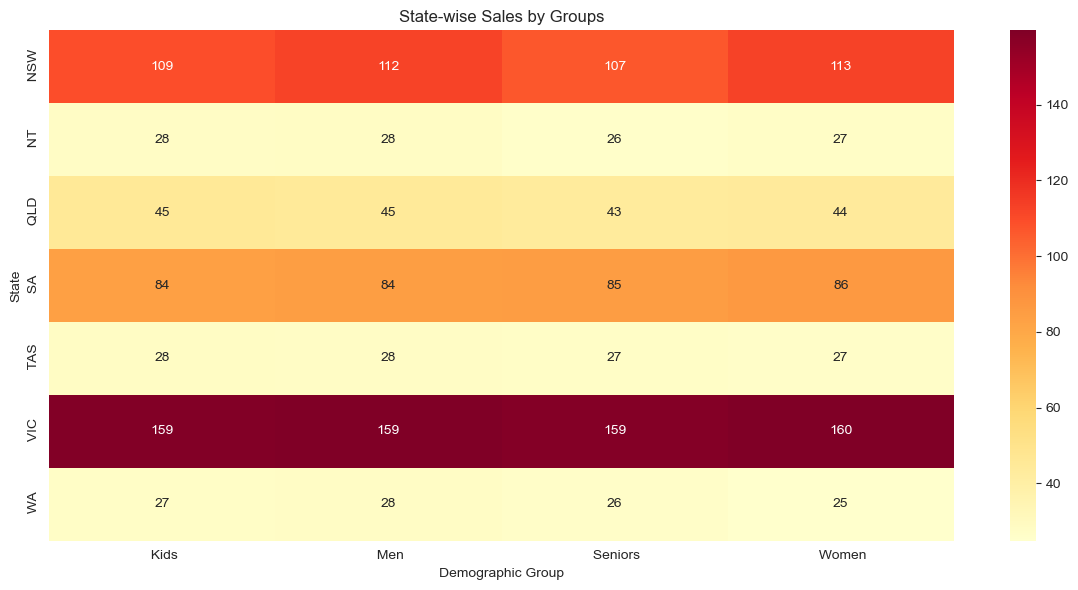

In [ ]:

# ==========================================
# Data Visualizations
# ==========================================

sns.set_style("whitegrid")
sns.set_palette("Set2")


# State-wise Sales by Demographic Group: kids, women, men, and seniors
print("Generating: State vs Demographic Group Heatmap...")
if 'State' in df.columns and 'Group' in df.columns:
    pivot_state_demo = df.pivot_table(values='Sales', index='State', columns='Group', aggfunc='sum', fill_value=0)
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_state_demo, annot=True, fmt='.0f', cmap='YlOrRd')
    plt.title('State-wise Sales by Groups')
    plt.xlabel('Demographic Group')
    plt.ylabel('State')
    plt.tight_layout()
    plt.savefig('dashboard_state_demo.png', dpi=300)
    plt.show()




Generating: Group-wise Sales Bar Chart...


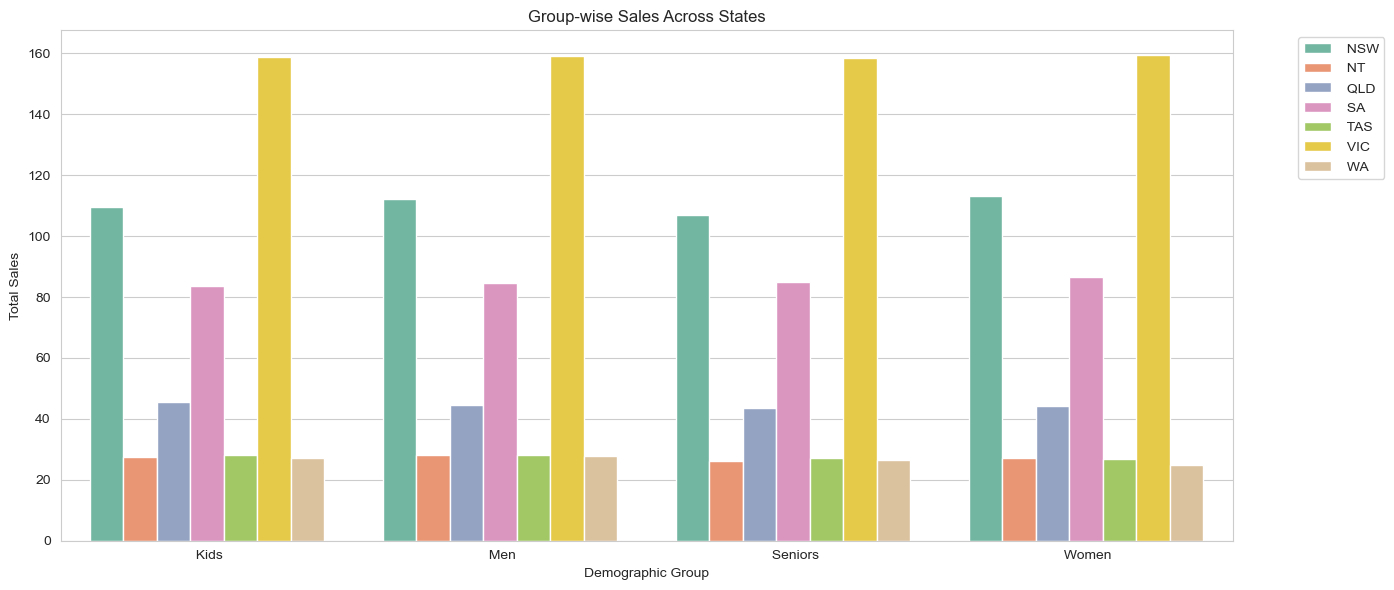

In [ ]:
# Group-wise Sales Across States (Bar Chart) ---
print("Generating: Group-wise Sales Bar Chart...")
if 'Group' in df.columns and 'State' in df.columns:
    group_state_sales = df.groupby(['Group', 'State'])['Sales'].sum().reset_index()
    plt.figure(figsize=(14, 6))
    sns.barplot(data=group_state_sales, x='Group', y='Sales', hue='State')
    plt.title('Group-wise Sales Across States')
    plt.xlabel('Demographic Group')
    plt.ylabel('Total Sales')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('dashboard_group_state.png', dpi=300)
    plt.show()

Generating: Time-of-Day Sales Pattern...


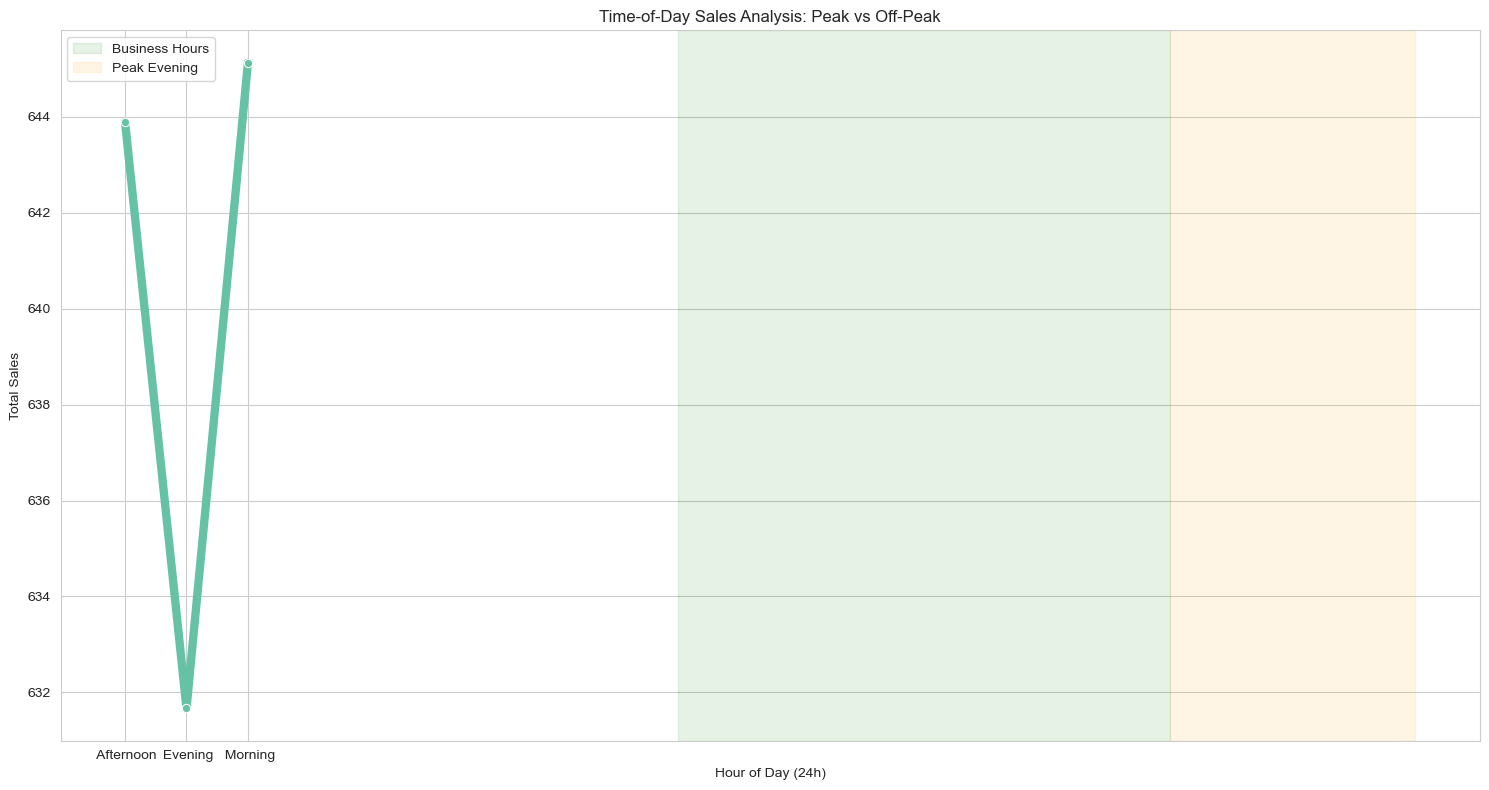

In [ ]:
# Time-of-Day Analysis (example Peak vs Off-Peak)

print("Generating: Time-of-Day Sales Pattern...")
if 'Time' in df.columns:  # Ensure you have an 'Hour' column (0-23)
    hourly_sales = df.groupby('Time')['Sales'].sum().reset_index()
    plt.figure(figsize=(15, 8))
    sns.lineplot(data=hourly_sales, x='Time', y='Sales', marker='o', linewidth=6)
    plt.title('Time-of-Day Sales Analysis: Peak vs Off-Peak')
    plt.xlabel('Hour of Day (24h)')
    plt.ylabel('Total Sales')
    plt.axvspan(9, 17, alpha=0.1, color='green', label='Business Hours')
    plt.axvspan(17, 21, alpha=0.1, color='orange', label='Peak Evening')
    plt.legend()
    plt.tight_layout()
    plt.savefig('dashboard_time_of_day.png', dpi=300)
    plt.show()

Generating: Time-Series Reports...


C:\Users\SETUP\AppData\Local\Temp\ipykernel_3888\3285456924.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_time.resample('M')['Sales'].sum()
C:\Users\SETUP\AppData\Local\Temp\ipykernel_3888\3285456924.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly.index.strftime('%b'), y=monthly.values, ax=axes[1,0], palette='Blues_d')
C:\Users\SETUP\AppData\Local\Temp\ipykernel_3888\3285456924.py:32: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df_time.resample('Q')['Sales'].sum()
C:\Users\SETUP\AppData\Local\Temp\ipykernel_3888\3285456924.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=

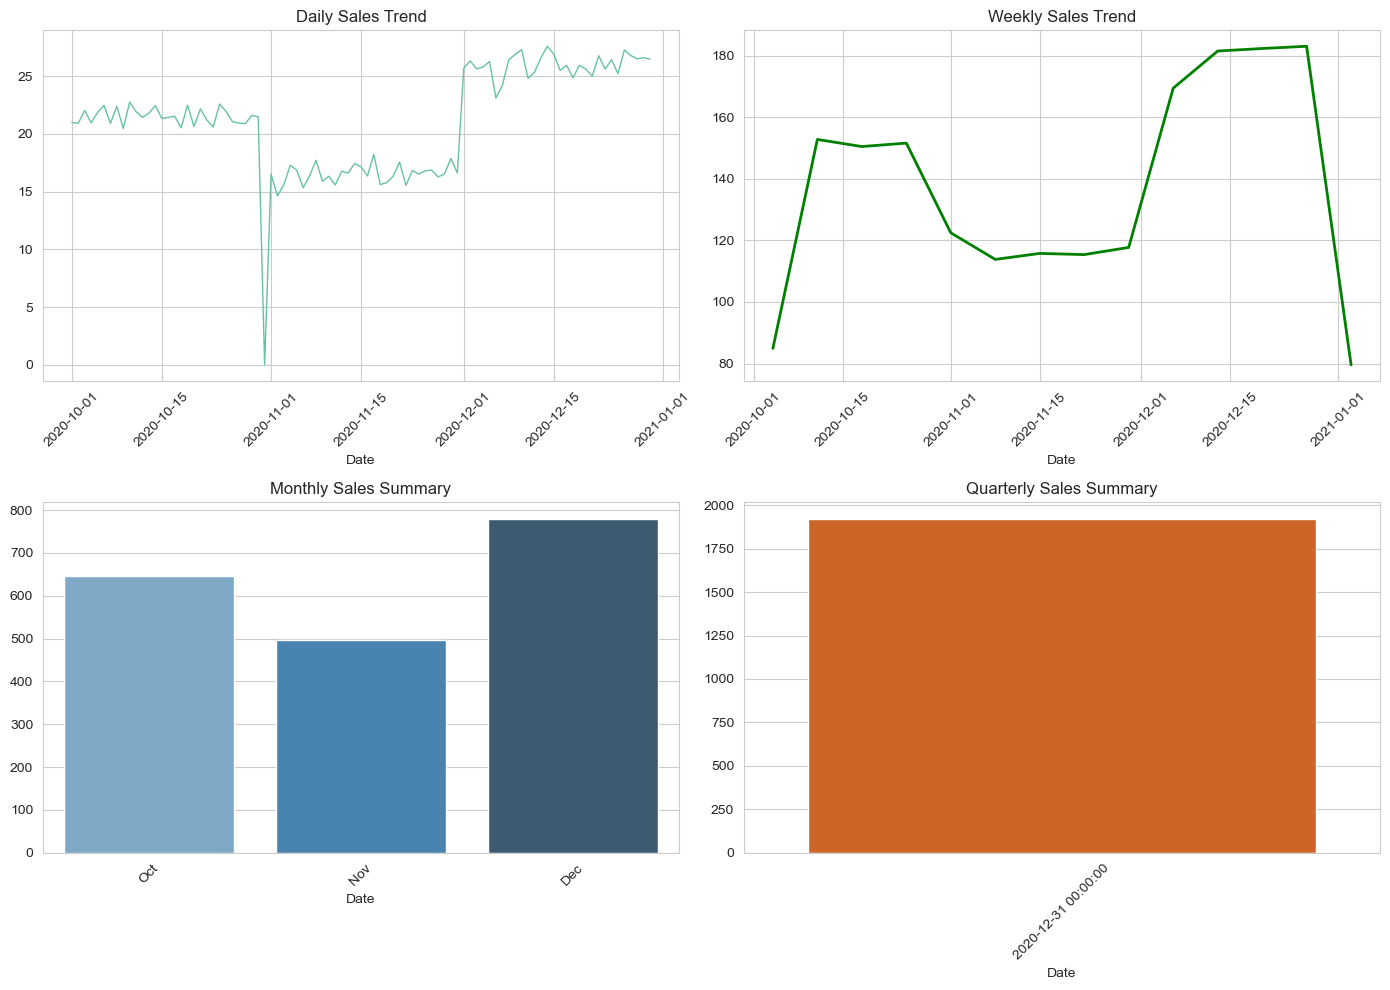

✓ All dashboard charts saved as PNG files.


In [ ]:
# ==========================================
# Time-Based Charts (Daily, Weekly, Monthly, Quarterly)
# ==========================================

print("Generating: Time-Series Reports...")

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df_time = df.set_index('Date')
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Daily
    daily = df_time.resample('D')['Sales'].sum()
    sns.lineplot(x=daily.index, y=daily.values, ax=axes[0,0], linewidth=1)
    axes[0,0].set_title('Daily Sales Trend')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Weekly
    weekly = df_time.resample('W')['Sales'].sum()
    sns.lineplot(x=weekly.index, y=weekly.values, ax=axes[0,1], color='green', linewidth=2)
    axes[0,1].set_title('Weekly Sales Trend')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Monthly
    monthly = df_time.resample('M')['Sales'].sum()
    sns.barplot(x=monthly.index.strftime('%b'), y=monthly.values, ax=axes[1,0], palette='Blues_d')
    axes[1,0].set_title('Monthly Sales Summary')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Quarterly
    quarterly = df_time.resample('Q')['Sales'].sum()
    sns.barplot(x=quarterly.index.strftime('%Y-Q%q'), y=quarterly.values, ax=axes[1,1], palette='Oranges_d')
    axes[1,1].set_title('Quarterly Sales Summary')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('dashboard_time_series.png', dpi=300)
    plt.show()
    
    print("✓ All dashboard charts saved as PNG files.")


In [ ]:
# ==========================================
# INFERENCE: Recommendation & Justification
# ==========================================

print("\n" + "="*60)
print("RECOMMENDATION: Why Seaborn for This Dashboard?")
print("="*60)
print("""
✓ Statistical Integration: Seaborn is built on top of Matplotlib but adds 
  built-in support for statistical aggregations (mean, CI, distributions) 
  without extra code.

✓ Aesthetic Defaults: Clean themes, color palettes, and label handling 
  reduce formatting time. Charts look presentation-ready instantly.

✓ Categorical Plot Support: Functions like barplot(), boxplot(), and 
  heatmap() handle grouped data (e.g., State × Demographic) natively.

✓ Time-Series Friendly: Works seamlessly with Pandas datetime indexes 
  for daily/weekly/monthly trends.

✓ Accessibility: High-contrast palettes and clear legends support 
  quick decision-making for non-technical stakeholders like S&M heads.

★ Alternative Considered: Plotly (for interactivity). 
  But for static reports, PDF exports, and JupyterLab notebooks, 
  Seaborn + Matplotlib offers simpler syntax and lighter dependencies.

★ Best Practice: Save charts as high-DPI PNGs (as done above) for 
  inclusion in PowerPoint/PDF reports to leadership.
""")
print("="*60)


RECOMMENDATION: Why Seaborn for This Dashboard?

✓ Statistical Integration: Seaborn is built on top of Matplotlib but adds 
  built-in support for statistical aggregations (mean, CI, distributions) 
  without extra code.

✓ Aesthetic Defaults: Clean themes, color palettes, and label handling 
  reduce formatting time. Charts look presentation-ready instantly.

✓ Categorical Plot Support: Functions like barplot(), boxplot(), and 
  heatmap() handle grouped data (e.g., State × Demographic) natively.

✓ Time-Series Friendly: Works seamlessly with Pandas datetime indexes 
  for daily/weekly/monthly trends.

✓ Accessibility: High-contrast palettes and clear legends support 
  quick decision-making for non-technical stakeholders like S&M heads.

★ Alternative Considered: Plotly (for interactivity). 
  But for static reports, PDF exports, and JupyterLab notebooks, 
  Seaborn + Matplotlib offers simpler syntax and lighter dependencies.

★ Best Practice: Save charts as high-DPI PNGs (as done a